In [1]:
from sklearn.preprocessing import StandardScaler
data = [[10, 2], [15, 5], [20, 3]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)

[[-1.22474487 -1.06904497]
 [ 0.          1.33630621]
 [ 1.22474487 -0.26726124]]


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, ['age']),
    ('cat', categorical_transformer, ['category'])
])

preprocessed_data = preprocessor.fit_transform(data)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [3]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


data = pd.DataFrame({
    'age': [25, 30, np.nan, 35, 40],
    'category': ['A', 'B', 'A', np.nan, 'C']
})

print("Original Data:")
print(data)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, ['age']),
    ('cat', categorical_transformer, ['category'])
])

preprocessed_data = preprocessor.fit_transform(data)

print("\nPreprocessed Data:")
print(preprocessed_data)

Original Data:
    age category
0  25.0        A
1  30.0        B
2   NaN        A
3  35.0      NaN
4  40.0        C

Preprocessed Data:
[[-1.5  1.   0.   0. ]
 [-0.5  0.   1.   0. ]
 [ 0.   1.   0.   0. ]
 [ 0.5  1.   0.   0. ]
 [ 1.5  0.   0.   1. ]]


In [4]:
import numpy as np

array = np.array([1, 2, 3, 4])
squared_array = np.square(array)

print(squared_array)

[ 1  4  9 16]


In [5]:
import pandas as pd

data = pd.DataFrame({
    'name': ['John', 'Jane', 'Jack'],
    'age': [28, 31, 34]
})

print(data)


   name  age
0  John   28
1  Jane   31
2  Jack   34


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

augmented_images = datagen.flow_from_directory('image_directory', target_size=(150, 150))

FileNotFoundError: [Errno 2] No such file or directory: 'image_directory'

In [7]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

print("Folders in current directory:")
print(os.listdir())

dataset_path = "/content/dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

print("Classes Found:", train_generator.class_indices)

images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

Folders in current directory:
['.config', 'sample_data']


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset'

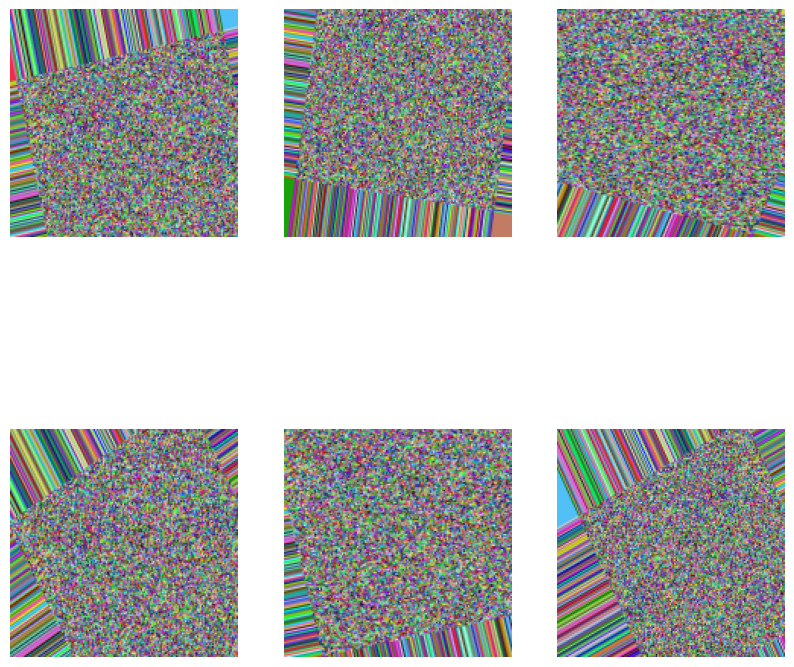

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image = np.random.rand(1, 150, 150, 3)

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

aug_iter = datagen.flow(image, batch_size=1)

plt.figure(figsize=(10,10))

for i in range(6):
    augmented_image = next(aug_iter)[0]
    plt.subplot(2,3,i+1)
    plt.imshow(augmented_image)
    plt.axis("off")

plt.show()